In [6]:
import pandas as pd
data = pd.read_csv(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\AgriGrow\data\clean data\final_dataset.csv')

In [7]:
data.columns

Index(['Year', 'Crop', 'State', 'Season', 'Seasonal_Temperature (°C)',
       'Seasonal_Rainfall (mm)', 'Fertilizer (kg/ha)', 'Pesticide (kg/ha)',
       'Nitrogen_High_%', 'Nitrogen_Medium_%', 'Nitrogen_Low_%',
       'Phosphorus_High_%', 'Phosphorus_Medium_%', 'Phosphorus_Low_%',
       'Potassium_High_%', 'Potassium_Medium_%', 'Potassium_Low_%',
       'Organic_Carbon_High_%', 'Organic_Carbon_Medium_%',
       'Organic_Carbon_Low_%', 'pH_Alkaline_%', 'pH_Acidic_%', 'pH_Neutral_%',
       'EC_NonSaline_%', 'EC_Saline_%', 'Sulphur_Sufficient_%',
       'Sulphur_Deficient_%', 'Iron_Sufficient_%', 'Iron_Deficient_%',
       'Zinc_Sufficient_%', 'Zinc_Deficient_%', 'Boron_Sufficient_%',
       'Boron_Deficient_%', 'Area (ha)', 'Production (tonnes)',
       'Yield (t/ha)'],
      dtype='object')

In [8]:
#Adding Target Variable
import numpy as np
data = data.sort_values(by=['State', 'Crop', 'Season', 'Year'])
data['Yield_Baseline_5Y'] = (
    data.groupby(['State', 'Crop', 'Season'])['Yield (t/ha)']
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(level=[0,1,2], drop=True)
    .shift(1)
)

ALPHA = 0.75
data['Crop_Failure_Risk'] = np.where(
    data['Yield (t/ha)'] < ALPHA * data['Yield_Baseline_5Y'],
    1,  
    0   
)
data.loc[data['Yield_Baseline_5Y'].isna(), 'Crop_Failure_Risk'] = np.nan

In [9]:
#Feature Selection
columns_to_drop = ['Year', 'Production (tonnes)', 'Yield (t/ha)', 
                   'Nitrogen_Low_%', 'Phosphorus_Low_%', 'Potassium_Low_%', 'Organic_Carbon_Low_%']
data = data.drop(columns= columns_to_drop)

In [10]:
#Dealing with imbalance
#scale_pos_weight: hyperparameter used in boosting algorithms like to handle severe data imbalance.
#If the model makes a mistake on a Non-Failure sample, the penalty (loss) is multiplied by 1.
# If the model makes a mistake on a Failure sample, the penalty (loss) is multiplied by the high value (W).
#W = count(non failure samples)/count(failure samples)
data_model_ready = data.dropna(subset=['Crop_Failure_Risk']).copy()
data_model_ready['Crop_Failure_Risk'] = data_model_ready['Crop_Failure_Risk'].astype(int)
Y = data_model_ready['Crop_Failure_Risk']
count_neg = (Y == 0).sum()
count_pos = (Y == 1).sum()
#print(f"Percentage of Failure = {(count_pos/(count_neg+count_pos))*100}") -> 13.4496%
scale_pos_weight = count_neg / count_pos

In [11]:
#Target Encoding: For high cardinality features like crop and state
#One Hot Encoding will fail because of high cardinality
#We will face the Curse of Dimensionality
#Target Encoding: Replaces a categorical label with the mean of the target variable for that specific category
#One-Hot Encoding: Converts a categorical variable into multiple binary columns (0s and 1s), where a '1' in a 
# column indicates the presence of that specific category.

# Encoding
from sklearn.model_selection import train_test_split
import numpy as np

X = data_model_ready.drop(columns=['Crop_Failure_Risk', 'Yield_Baseline_5Y']).copy()
Y = data_model_ready['Crop_Failure_Risk'].astype(int).copy()
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.3, 
    random_state=42,
    stratify=Y #risk = 1 cases are split evenly
)
count_neg = (Y_train == 0).sum()
count_pos = (Y_train == 1).sum()
scale_pos_weight = count_neg / count_pos

from category_encoders import TargetEncoder
target_encode_cols = ['Crop', 'State']
encoder = TargetEncoder(cols=target_encode_cols)
encoder.fit(X_train, Y_train) 
X_train_encoded = encoder.transform(X_train)
X_test_encoded = encoder.transform(X_test)

ohe_col = ['Season']
X_train_final = pd.get_dummies(X_train_encoded, columns=ohe_col, drop_first=True)
X_test_final = pd.get_dummies(X_test_encoded, columns=ohe_col, drop_first=True)

train_cols = X_train_final.columns
X_test_final = X_test_final.reindex(columns=train_cols, fill_value=0)

In [12]:
#Feature Selection
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np

selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_train_final, Y_train)
p_values_f = pd.Series(selector_f.pvalues_, index=X_train_final.columns)
f_scores = pd.Series(selector_f.scores_, index=X_train_final.columns)
anova_summary = pd.DataFrame({
    'F_Score': f_scores,
    'P_Value': p_values_f
}).sort_values(by='P_Value', ascending=True)
significant_features = p_values_f[p_values_f < 0.05].index.tolist()
target_encoded_features = [col for col in X_train_final.columns if 'TargetEncoded' in col]
final_features = list(set(significant_features) | set(target_encoded_features))
X_train_tuned = X_train_final[final_features].copy()
X_test_tuned = X_test_final[final_features].copy()

print("\nANOVA F-Test Feature Selection Complete")
print(f"Total Features Before Selection: {X_train_final.shape[1]}")
print(f"Total Final Features Selected: {X_train_tuned.shape[1]}")
print("\nFinal List of Features Selected:")
feature_list = X_train_tuned.columns.tolist()
print('\n'.join(feature_list))


ANOVA F-Test Feature Selection Complete
Total Features Before Selection: 33
Total Final Features Selected: 29

Final List of Features Selected:
Nitrogen_Medium_%
EC_NonSaline_%
Organic_Carbon_High_%
Season_Summer     
Potassium_High_%
Crop
Potassium_Medium_%
State
Boron_Sufficient_%
Phosphorus_Medium_%
Iron_Deficient_%
Season_Kharif     
Sulphur_Deficient_%
pH_Alkaline_%
Organic_Carbon_Medium_%
Fertilizer (kg/ha)
Season_Rabi       
Iron_Sufficient_%
Season_Winter     
Nitrogen_High_%
Season_Whole Year 
Seasonal_Rainfall (mm)
pH_Acidic_%
EC_Saline_%
Sulphur_Sufficient_%
Phosphorus_High_%
pH_Neutral_%
Boron_Deficient_%
Seasonal_Temperature (°C)


In [13]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

rf_param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_base = RandomForestClassifier(
    class_weight='balanced_subsample', 
    random_state=42
)

rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=50,           
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1,           
    random_state=42
)

optimal_threshold = 0.30
rf_random.fit(X_train_tuned, Y_train) 
best_rf = rf_random.best_estimator_
y_pred_rf = best_rf.predict(X_test_tuned) 
y_proba_rf = best_rf.predict_proba(X_test_tuned)[:, 1] 
y_pred_optimal = (y_proba_rf >= optimal_threshold).astype(int)

print("\nModel Performance on Test Set")
print(f"Accuracy: {accuracy_score(Y_test, y_pred_rf):.4f}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_proba_rf):.4f}")
print("\nClassification Report:\n", classification_report(Y_test, y_pred_optimal, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_optimal))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Model Performance on Test Set
Accuracy: 0.8636
ROC AUC: 0.7854

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.83      0.88      5103
           1       0.34      0.55      0.42       793

    accuracy                           0.80      5896
   macro avg       0.63      0.69      0.65      5896
weighted avg       0.84      0.80      0.82      5896


Confusion Matrix:
 [[4261  842]
 [ 356  437]]


In [14]:
from sklearn.metrics import f1_score, precision_score, recall_score
thresholds = np.arange(0.10, 0.71, 0.05)
results = []
print("Testing Thresholds for Random Forest (F1 Score for Class 1)")
for t in thresholds:
    y_pred_new = (y_proba_rf >= t).astype(int)
    f1 = f1_score(Y_test, y_pred_new, pos_label=1, zero_division=0)
    precision = precision_score(Y_test, y_pred_new, pos_label=1, zero_division=0)
    recall = recall_score(Y_test, y_pred_new, pos_label=1, zero_division=0)
    results.append({'Threshold': t, 'F1_Score': f1, 'Recall': recall, 'Precision': precision})
    
results_df = pd.DataFrame(results).sort_values(by='F1_Score', ascending=False)
optimal_threshold = results_df.iloc[0]['Threshold']
print(results_df.head())
print(f"\nOptimal Threshold: {optimal_threshold:.2f}")

Testing Thresholds for Random Forest (F1 Score for Class 1)
   Threshold  F1_Score    Recall  Precision
4       0.30  0.421815  0.551072   0.341673
5       0.35  0.413483  0.464061   0.372847
3       0.25  0.405229  0.625473   0.299698
6       0.40  0.404145  0.393443   0.415446
2       0.20  0.397222  0.721311   0.274078

Optimal Threshold: 0.30


In [15]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer, accuracy_score, classification_report, confusion_matrix

xgb_param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

xgb_base = xgb.XGBClassifier(
    random_state=42, 
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight 
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scorer = make_scorer(roc_auc_score)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=50,             
    cv=cv_strategy,       
    scoring=auc_scorer,    
    verbose=1,
    n_jobs=-1,             
    random_state=42
)

xgb_random_search.fit(X_train_tuned, Y_train) 
best_xgb = xgb_random_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_tuned)
y_proba_xgb = best_xgb.predict_proba(X_test_tuned)[:, 1] 

print("\nModel Performance on Test Set - XGBoost")
print(f"Accuracy: {accuracy_score(Y_test, y_pred_xgb):.4f}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_proba_xgb):.4f}")
print("\nClassification Report:\n", classification_report(Y_test, y_pred_xgb, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_xgb))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\Hp\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:25:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Performance on Test Set - XGBoost
Accuracy: 0.7685
ROC AUC: 0.7643

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.80      0.86      5103
           1       0.30      0.56      0.39       793

    accuracy                           0.77      5896
   macro avg       0.61      0.68      0.63      5896
weighted avg       0.84      0.77      0.79      5896


Confusion Matrix:
 [[4086 1017]
 [ 348  445]]


In [16]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer

lgbm_param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

lgbm_base = lgb.LGBMClassifier(
    objective='binary', 
    metric='auc',
    random_state=42,
    scale_pos_weight=scale_pos_weight 
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scorer = make_scorer(roc_auc_score)

lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_dist,
    n_iter=50,            
    cv=cv_strategy,        
    scoring=auc_scorer,    
    verbose=1,
    n_jobs=-1,             
    random_state=42
)

lgbm_random_search.fit(X_train_tuned, Y_train) 
best_lgbm = lgbm_random_search.best_estimator_
y_proba_lgbm = best_lgbm.predict_proba(X_test_tuned)[:, 1] 
y_pred_lgbm_default = best_lgbm.predict(X_test_tuned) 

print("\nModel Performance on Test Set - LightGBM (Default 0.5 Threshold)")
print(f"Accuracy: {accuracy_score(Y_test, y_pred_lgbm_default):.4f}")
print(f"ROC AUC: {roc_auc_score(Y_test, y_proba_lgbm):.4f}")
print("\nClassification Report:\n", classification_report(Y_test, y_pred_lgbm_default, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_lgbm_default))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1850, number of negative: 11905
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000763 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 13755, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134497 -> initscore=-1.861773
[LightGBM] [Info] Start training from score -1.861773
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

Final Model Comparison Table
               F1-Score (Class 1)  ROC AUC  Recall (Class 1)
Model                                                       
Random Forest                0.42   0.7854              0.55
XGBoost                      0.39   0.7620              0.54
LightGBM                     0.43   0.7713              0.58


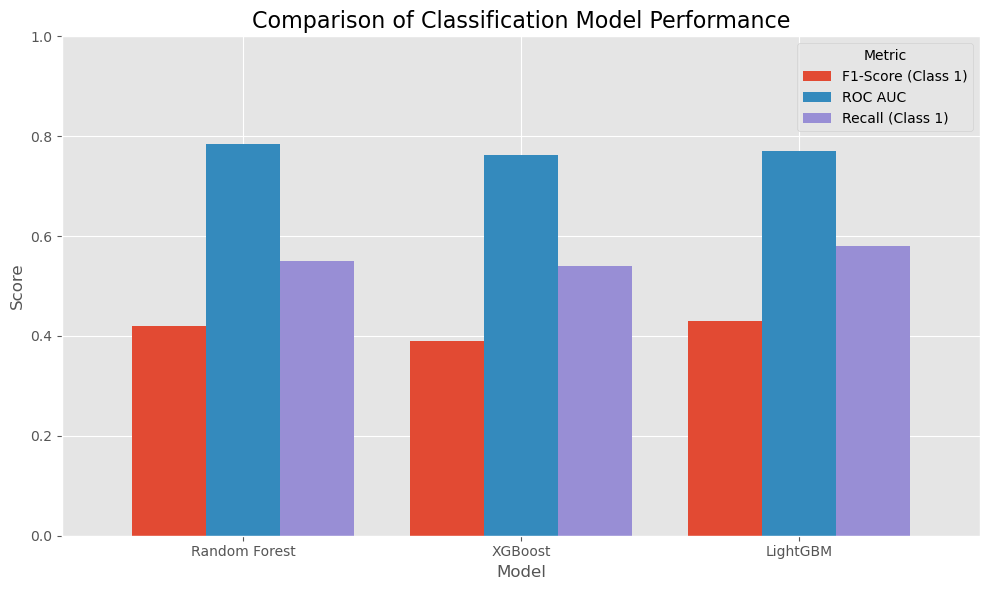

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rf_f1 = 0.42
rf_roc_auc = 0.7854
rf_recall = 0.55

xgb_f1 = 0.39
xgb_roc_auc = 0.7620
xgb_recall = 0.54

lgbm_f1 = 0.43 
lgbm_roc_auc = 0.7713
lgbm_recall = 0.58 
lgbm_fn = 348 
lgbm_fp = 952 

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'F1-Score (Class 1)': [rf_f1, xgb_f1, lgbm_f1],
    'ROC AUC': [rf_roc_auc, xgb_roc_auc, lgbm_roc_auc],
    'Recall (Class 1)': [rf_recall, xgb_recall, lgbm_recall]
}).set_index('Model')

print("Final Model Comparison Table")
print(comparison_df.round(4))

metrics_to_plot = ['F1-Score (Class 1)', 'ROC AUC', 'Recall (Class 1)']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))

comparison_df[metrics_to_plot].plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Comparison of Classification Model Performance', fontsize=16)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim(0, 1.0)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Metric', loc='upper right')
plt.tight_layout()
plt.show()

lgbm_results_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'ROC AUC', 
        'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)', 
        'True Negatives (TN)', 'False Positives (FP)', 
        'False Negatives (FN)', 'True Positives (TP)'
    ],
    'Value': [
        0.7800,
        lgbm_roc_auc, 
        0.3200, 
        lgbm_recall, 
        lgbm_f1,
        4155, 
        lgbm_fp,
        lgbm_fn,
        459
    ]
})


Top 15 Feature Importances (LightGBM)
pH_Alkaline_%                  96
Nitrogen_High_%                96
pH_Acidic_%                    97
Boron_Sufficient_%            100
Organic_Carbon_Medium_%       105
Organic_Carbon_High_%         123
Nitrogen_Medium_%             125
Potassium_High_%              127
EC_NonSaline_%                138
Phosphorus_Medium_%           140
State                         141
Crop                          931
Fertilizer (kg/ha)           1253
Seasonal_Temperature (°C)    1312
Seasonal_Rainfall (mm)       1336
dtype: int32


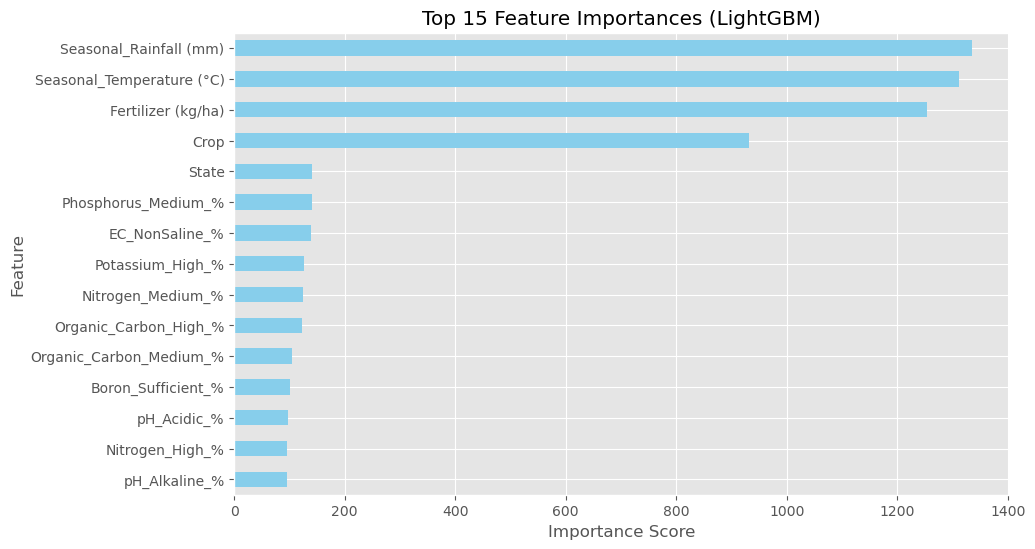

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances_lgbm = pd.Series(best_lgbm.feature_importances_, 
                                     index=X_train_tuned.columns)

top_15_features_lgbm = feature_importances_lgbm.nlargest(15).sort_values(ascending=True)

print("Top 15 Feature Importances (LightGBM)")
print(top_15_features_lgbm)

plt.figure(figsize=(10, 6))
top_15_features_lgbm.plot(kind='barh', color='skyblue')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [19]:
import pickle
final_model = best_lgbm 
filename = 'final_crop_failure_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(final_model, file)